Hypothesis testing and statistical inference

We use `insurance_cleaned.csv` from Task 1, in original units. It contains 1,337 records after one exact duplicate was removed. No age, dependents, BMI or charge exclusions remain.

All three tests use **α = 0.05**. The first two alternatives are two-sided: we test for a difference, not a preselected direction. We reject H₀ when p ≤ α; otherwise, we do not reject H₀.

This is an exploratory classroom analysis. Independent observations are assumed; the sampling design and population representativeness are not established. Results therefore illustrate statistical inference rather than establish facts about all US residents. The three p-values are unadjusted, with 0.05 applied to each test separately.

Source: [Medical Cost Personal Dataset on Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

df = pd.read_csv("insurance_cleaned.csv")
alpha = 0.05

print("Rows and columns:", df.shape)
print("Missing values in test columns:")
print(df[["charges", "smoker", "has_children"]].isnull().sum())
display(df.head())

Rows and columns: (1337, 9)
Missing values in test columns:
charges         0
smoker          0
has_children    0
dtype: int64


,age,sex,bmi,children,smoker,region,charges,bmi_category,has_children
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,0
1,18,male,33.770,1,no,southeast,1725.55230,Obesity class 1,1
2,28,male,33.000,3,no,southeast,4449.46200,Obesity class 1,1
3,33,male,22.705,0,no,northwest,21984.47061,Healthy weight,0
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,0


One-sample t-test: mean medical charges versus $10,000

**H₀:** The population mean medical charge is $10,000.

**H₁:** The population mean medical charge differs from $10,000.

$10,000 is a hypothetical benchmark selected for this exercise, not a documented US average. Charges are skewed, but the large sample supports an approximate t-test for the mean, assuming independent observations. We retain extreme costs and report a 95% confidence interval for the mean.

In [2]:
charges = df["charges"]
benchmark = 10000

print("Sample size:", len(charges))
print(f"Sample mean: ${charges.mean():,.2f}")
print(f"Sample median: ${charges.median():,.2f}")
print(f"Sample standard deviation: ${charges.std():,.2f}")
print(f"Skewness: {charges.skew():.2f}")

Sample size: 1337
Sample mean: $13,279.12
Sample median: $9,386.16
Sample standard deviation: $12,110.36
Skewness: 1.52


In [3]:
one_sample = stats.ttest_1samp(charges, popmean=benchmark)
mean_interval = one_sample.confidence_interval(confidence_level=0.95)

print("Significance level:", alpha)
print(f"t-statistic: {one_sample.statistic:.3f}")
print(f"Degrees of freedom: {one_sample.df:.0f}")
print(f"p-value: {one_sample.pvalue:.6g}")
print(f"Mean minus benchmark: ${charges.mean() - benchmark:,.2f}")
print(f"95% confidence interval for the mean: ${mean_interval.low:,.2f} to ${mean_interval.high:,.2f}")

if one_sample.pvalue <= alpha:
    decision_one = "Reject H0"
    print("Decision: Reject H0 because p <= 0.05.")
    print("Conclusion: There is enough evidence that average medical charges differ from the $10,000 benchmark, assuming the test conditions hold.")
else:
    decision_one = "Do not reject H0"
    print("Decision: Do not reject H0 because p > 0.05.")
    print("Conclusion: There is not enough evidence to reject the claim that the population mean charge is $10,000. This does not prove H0 is true.")

Significance level: 0.05
t-statistic: 9.901
Degrees of freedom: 1336
p-value: 2.37837e-22
Mean minus benchmark: $3,279.12
95% confidence interval for the mean: $12,629.39 to $13,928.85
Decision: Reject H0 because p <= 0.05.
Conclusion: There is enough evidence that average medical charges differ from the $10,000 benchmark, assuming the test conditions hold.


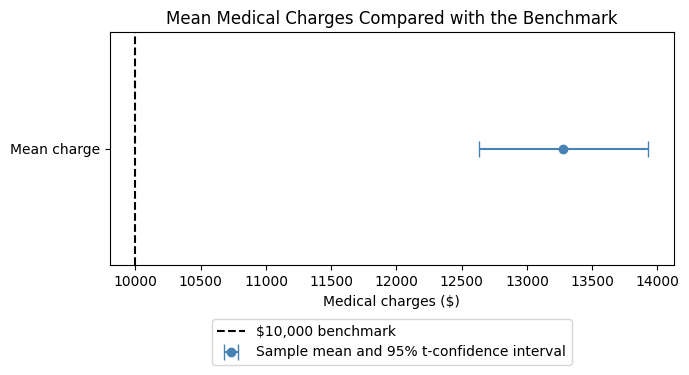

In [4]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    charges.mean(), 0,
    xerr=[[charges.mean() - mean_interval.low], [mean_interval.high - charges.mean()]],
    fmt="o", color="steelblue", capsize=6, label="Sample mean and 95% t-confidence interval"
)
plt.axvline(benchmark, color="black", linestyle="--", label="$10,000 benchmark")

plt.yticks([0], ["Mean charge"])
plt.xlabel("Medical charges ($)")
plt.title("Mean Medical Charges Compared with the Benchmark")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2))
plt.tight_layout()
plt.show()

Two-sample t-test: smokers versus non-smokers

**H₀:** Smokers and non-smokers have equal population mean medical charges.

**H₁:** Their population mean medical charges differ.

The groups contain different records. We use **Welch's t-test**, which does not assume equal variances or equal group sizes. Both samples are large, supporting the approximate test despite skewness; independence remains an assumption. This is an unadjusted group comparison, not a causal test of smoking.

In [5]:
smokers = df.loc[df["smoker"] == "yes", "charges"]
non_smokers = df.loc[df["smoker"] == "no", "charges"]

group_summary = df.groupby("smoker")["charges"].agg(["count", "mean", "median", "std", "skew"])
display(group_summary.round(2))

,count,mean,median,std,skew
smoker,,,,,
no,1063,8440.66,7345.73,5992.97,1.54
yes,274,32050.23,34456.35,11541.55,0.13


In [6]:
two_sample = stats.ttest_ind(smokers, non_smokers, equal_var=False)
difference_interval = two_sample.confidence_interval(confidence_level=0.95)
mean_difference = smokers.mean() - non_smokers.mean()

print("Significance level:", alpha)
print(f"Welch t-statistic: {two_sample.statistic:.3f}")
print(f"Degrees of freedom: {two_sample.df:.2f}")
print(f"p-value: {two_sample.pvalue:.6g}")
print(f"Mean charges, smokers: ${smokers.mean():,.2f}")
print(f"Mean charges, non-smokers: ${non_smokers.mean():,.2f}")
print(f"Mean difference (smokers minus non-smokers): ${mean_difference:,.2f}")
print(f"95% confidence interval for the mean difference: ${difference_interval.low:,.2f} to ${difference_interval.high:,.2f}")

if two_sample.pvalue <= alpha:
    decision_two = "Reject H0"
    print("Decision: Reject H0 because p <= 0.05.")
    print("Conclusion: There is enough evidence that smokers and non-smokers have different average medical charges, assuming the test conditions hold.")
else:
    decision_two = "Do not reject H0"
    print("Decision: Do not reject H0 because p > 0.05.")
    print("Conclusion: There is not enough evidence to reject equal population mean charges. This does not prove that the means are equal.")

Significance level: 0.05
Welch t-statistic: 32.742
Degrees of freedom: 311.88
p-value: 6.26172e-103
Mean charges, smokers: $32,050.23
Mean charges, non-smokers: $8,440.66
Mean difference (smokers minus non-smokers): $23,609.57
95% confidence interval for the mean difference: $22,190.79 to $25,028.35
Decision: Reject H0 because p <= 0.05.
Conclusion: There is enough evidence that smokers and non-smokers have different average medical charges, assuming the test conditions hold.


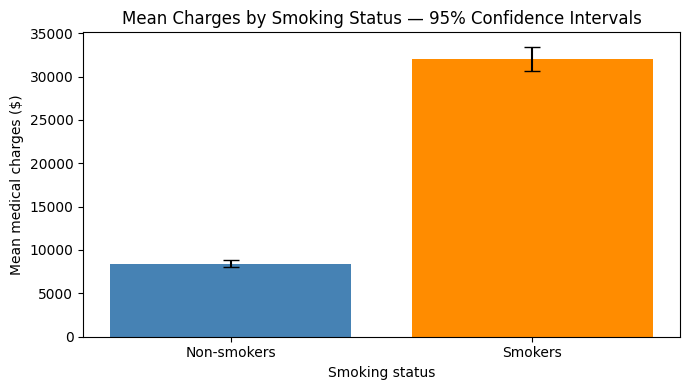

In [7]:
# These intervals describe each group mean; the test above compares their difference.
smoker_interval = stats.t.interval(
    0.95, df=len(smokers) - 1, loc=smokers.mean(), scale=stats.sem(smokers)
)
non_smoker_interval = stats.t.interval(
    0.95, df=len(non_smokers) - 1, loc=non_smokers.mean(), scale=stats.sem(non_smokers)
)

means = [non_smokers.mean(), smokers.mean()]
errors = [
    [means[0] - non_smoker_interval[0], means[1] - smoker_interval[0]],
    [non_smoker_interval[1] - means[0], smoker_interval[1] - means[1]]
]

plt.figure(figsize=(7, 4))
plt.bar(
    ["Non-smokers", "Smokers"], means,
    yerr=errors, capsize=6, color=["steelblue", "darkorange"]
)
plt.xlabel("Smoking status")
plt.ylabel("Mean medical charges ($)")
plt.title("Mean Charges by Smoking Status — 95% Confidence Intervals")
plt.tight_layout()
plt.show()

Chi-square test: smoking and children listed on insurance

**Question:** Is the percentage of smokers different between people with and without children listed on their insurance?

**H₀:** The percentage of smokers is the same in both groups in the population.

**H₁:** The percentage of smokers differs between the two groups in the population.

We compare two yes/no columns: `smoker` and `has_children`. Here, "insured children" means the children/dependents counted in the dataset; it does not necessarily mean biological children. `has_children = 0` means none listed, and `1` means at least one listed.

We count smokers and non-smokers in each group. Then we check that every expected count is at least 5. Expected counts are the counts we would expect if H₀ were true. Each person is assumed to be an independent observation. The test checks an association, not cause and effect.

In [8]:
# Rows show smoking status; columns show whether insured children are listed.
observed = pd.crosstab(df["smoker"], df["has_children"])
observed = observed.reindex(index=["no", "yes"], columns=[0, 1], fill_value=0)
observed.index = ["Non-smoker", "Smoker"]
observed.columns = ["No insured children", "Has insured children"]

print("Number of people in each group:")
display(observed)

# Divide by each column total because the two groups have different sizes.
smoking_percentages = observed.loc["Smoker"] / observed.sum(axis=0) * 100
print("Percentage of smokers in each group:")
display(smoking_percentages.round(2).rename("Smokers (%)").to_frame())

Number of people in each group:


,No insured children,Has insured children
Non-smoker,458,605
Smoker,115,159


Percentage of smokers in each group:


,Smokers (%)
No insured children,20.07
Has insured children,20.81


In [9]:
# Pearson's chi-square test, without a continuity correction.
chi_stat, chi_p, chi_df, expected = stats.chi2_contingency(observed, correction=False)

expected_table = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
print("Expected counts if the smoking percentage were the same:")
display(expected_table.round(2))

expected_ok = (expected >= 5).all()
print(f"Smallest expected count: {expected.min():.2f}")
print("All expected counts are at least 5:", expected_ok)

Expected counts if the smoking percentage were the same:


,No insured children,Has insured children
Non-smoker,455.57,607.43
Smoker,117.43,156.57


Smallest expected count: 117.43
All expected counts are at least 5: True


In [10]:
print("Significance level:", alpha)
print(f"Chi-square statistic: {chi_stat:.3f}")
print("Degrees of freedom:", chi_df)
print(f"p-value: {chi_p:.6g}")

if not expected_ok:
    decision_chi = "Review expected counts"
    print("Some expected counts are too small. Review the test before drawing a conclusion.")
elif chi_p <= alpha:
    decision_chi = "Reject H0"
    print("Decision: Reject H0 because p <= 0.05.")
    print("Conclusion: There is enough evidence that the smoking percentage differs between people with and without insured children.")
else:
    decision_chi = "Do not reject H0"
    print("Decision: Do not reject H0 because p > 0.05.")
    print("Conclusion: There is not enough evidence that the smoking percentage differs between people with and without insured children.")
    print("This does not prove that the percentages are exactly equal.")

Significance level: 0.05
Chi-square statistic: 0.111
Degrees of freedom: 1
p-value: 0.739517
Decision: Do not reject H0 because p > 0.05.
Conclusion: There is not enough evidence that the smoking percentage differs between people with and without insured children.
This does not prove that the percentages are exactly equal.


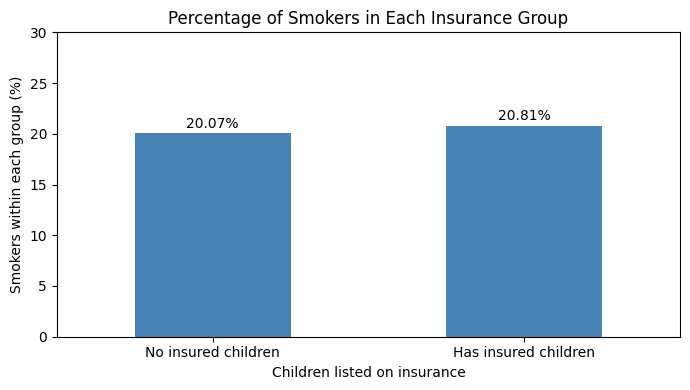

In [11]:
ax = smoking_percentages.plot.bar(figsize=(7, 4), color="steelblue")

for position, percentage in enumerate(smoking_percentages):
    ax.text(position, percentage + 0.5, f"{percentage:.2f}%", ha="center")

plt.title("Percentage of Smokers in Each Insurance Group")
plt.xlabel("Children listed on insurance")
plt.ylabel("Smokers within each group (%)")
plt.ylim(0, max(30, smoking_percentages.max() + 5))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Results summary

Statistical significance is not the size or practical importance of a difference. A non-significant result means insufficient evidence to reject H₀, not proof that H₀ is true. Confidence intervals and the observed differences help interpret the two mean comparisons.

In [12]:
results = pd.DataFrame({
    "Test": ["One-sample t-test", "Welch two-sample t-test", "Chi-square test"],
    "Statistic": [one_sample.statistic, two_sample.statistic, chi_stat],
    "p-value": [one_sample.pvalue, two_sample.pvalue, chi_p],
    "Alpha": [alpha, alpha, alpha],
    "Decision": [decision_one, decision_two, decision_chi]
})

display(results.style.format({"Statistic": "{:.3f}", "p-value": "{:.6g}", "Alpha": "{:.2f}"}))

,Test,Statistic,p-value,Alpha,Decision
0,One-sample t-test,9.901,2.37837e-22,0.05,Reject H0
1,Welch two-sample t-test,32.742,6.26172e-103,0.05,Reject H0
2,Chi-square test,0.111,0.739517,0.05,Do not reject H0
